# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv("aviation_cleaned.csv")

C:\Users\dkimasar.CO-OPBANK\AppData\Local\Temp\ipykernel_23940\151469234.py:1: DtypeWarning: Columns (6,7,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("aviation_cleaned.csv")


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [4]:
#Small vs Large Aircraft Classification

df["Aircraft_Size"] = np.where(
    df["Total.Passengers"] < 20, "Small", "Large"
)


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

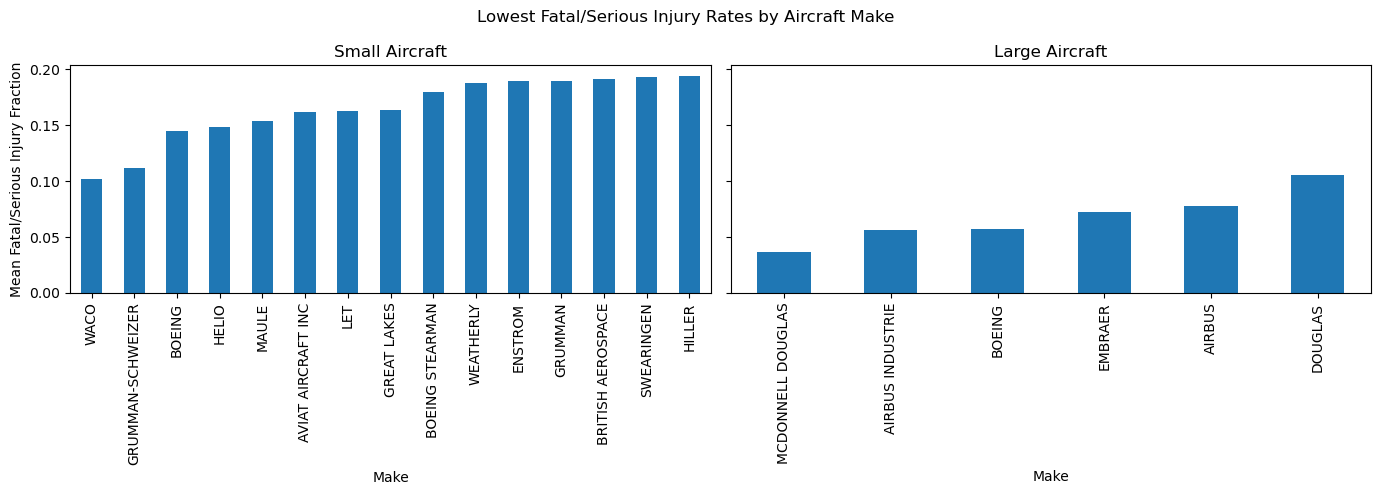

In [5]:
#Lowest Injury Risk – Small Aircraft

small_df = df[df["Aircraft_Size"] == "Small"]

small_make_stats = (
    small_df.groupby("Make")
    .agg(
        mean_injury=("Fatal_Serious_Fraction", "mean"),
        count=("Fatal_Serious_Fraction", "size")
    )
    .query("count >= 50")
    .sort_values("mean_injury")
    .head(15)
)

# Lowest Injury Risk – Large Aircraft

large_df = df[df["Aircraft_Size"] == "Large"]

large_make_stats = (
    large_df.groupby("Make")
    .agg(
        mean_injury=("Fatal_Serious_Fraction", "mean"),
        count=("Fatal_Serious_Fraction", "size")
    )
    .query("count >= 50")
    .sort_values("mean_injury")
    .head(15)
)

#chart


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

small_make_stats["mean_injury"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Small Aircraft")
axes[0].set_ylabel("Mean Fatal/Serious Injury Fraction")

large_make_stats["mean_injury"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Large Aircraft")

plt.suptitle("Lowest Fatal/Serious Injury Rates by Aircraft Make")
plt.tight_layout()
plt.show()



**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

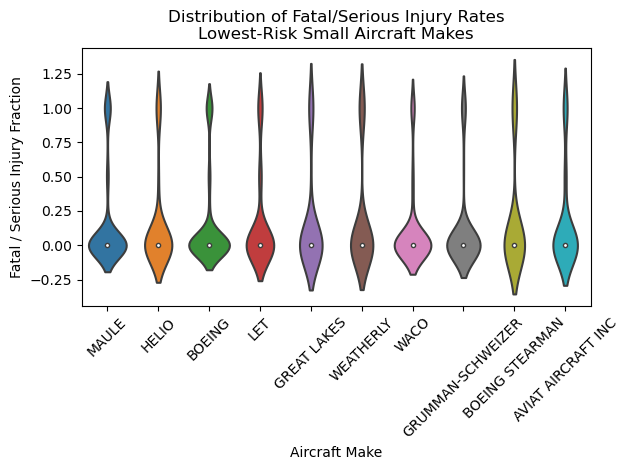

In [7]:
# Select the 10 small-aircraft makes with the lowest mean fatal/serious injury rates
top10_small = small_make_stats.head(10).index

# Violin plot showing distribution of injury rates
sns.violinplot(
    data=small_df[small_df["Make"].isin(top10_small)],
    x="Make",
    y="Fatal_Serious_Fraction"
)


plt.title(
    "Distribution of Fatal/Serious Injury Rates\nLowest-Risk Small Aircraft Makes"
)
plt.xlabel("Aircraft Make")
plt.ylabel("Fatal / Serious Injury Fraction")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

c:\Users\dkimasar.CO-OPBANK\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\dkimasar.CO-OPBANK\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


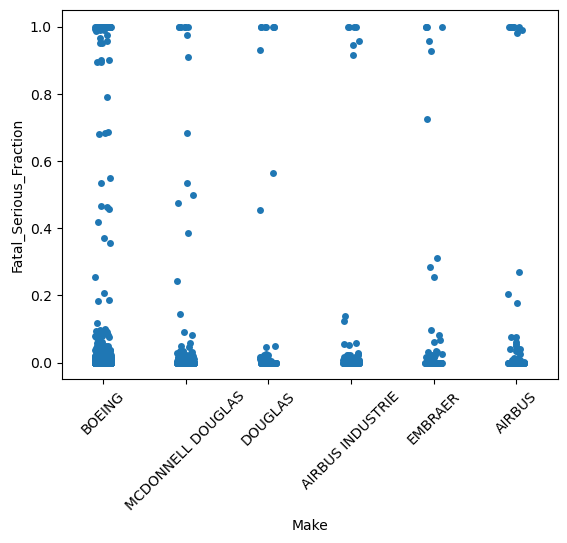

In [8]:
large_df = df[df["Aircraft_Size"] == "Large"]

large_make_stats = (
    large_df.groupby("Make")
    .agg(
        mean_injury=("Fatal_Serious_Fraction", "mean"),
        count=("Fatal_Serious_Fraction", "size")
    )
    .query("count >= 50")
    .sort_values("mean_injury")
    .head(10)
)

sns.stripplot(
    data=large_df[large_df["Make"].isin(large_make_stats.index)],
    x="Make",
    y="Fatal_Serious_Fraction"
)
plt.xticks(rotation=45)
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [10]:
# Aircraft Destruction Rates
destruction_rates = (
    df.groupby(["Aircraft_Size", "Make"])
    .Destroyed.mean()
    .reset_index()
    .sort_values("Destroyed")
    .head(15)
)
destruction_rates

,Aircraft_Size,Make,Destroyed
0,Large,AERO COMMANDER,0.000000
30,Large,SWEARINGEN,0.000000
29,Large,SIKORSKY,0.000000
28,Large,RAYTHEON AIRCRAFT COMPANY,0.000000
26,Large,MOONEY,0.000000
10,Large,CAMERON,0.000000
22,Large,HUGHES,0.000000
21,Large,GULFSTREAM,0.000000
19,Large,GATES LEARJET,0.000000
14,Large,DEHAVILLAND,0.000000


#### Provide a short discussion on your findings for your summary statistics and plots:
The plotted results consistently indicate that risk is not uniformly distributed across manufacturers, and that aircraft size and usage context (small vs. large aircraft) play an important role.
•	Small aircraft-makes generally show higher variability in outcomes, with wider spreads in fatal/serious injury fractions.
•	Large aircraft makes display lower central tendencies and tighter distributions, suggesting more consistency and generally lower severe outcome risk.
•	The violin plots highlight right skewed distributions, meaning that while most incidents result in low fatal or serious injury fractions, a small number of events drive higher severity outcomes.

## Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
For organizations prioritizing risk minimization, fleet selection should favor manufacturers with low median injury fractions and tight distributions, as these indicate both lower severity and greater predictability of outcomes.

## Comment on the calculated statistics and any corresponding distributions you have visualized.
•	Medians provide a better “typical” measure than means because the distributions are heavily skewed. 
•	IQRs clearly show that variability differs substantially by make, even when medians are similar. 
•	The violin plots reveal long upper tails, confirming that rare but severe events dominate risk perception. 
•	Scatter plots reinforce that large aircraft manufacturers cluster tightly at low risk, while small aircraft manufacturers show broader and more heterogeneous outcomes.


### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

In [ ]:
# Ensure at least 10 observations per Make (used by both sections)
filtered_df = (
    df.groupby(["Aircraft_Size", "Make"])
    .filter(lambda x: len(x) >= 10)
)

**Larger planes**

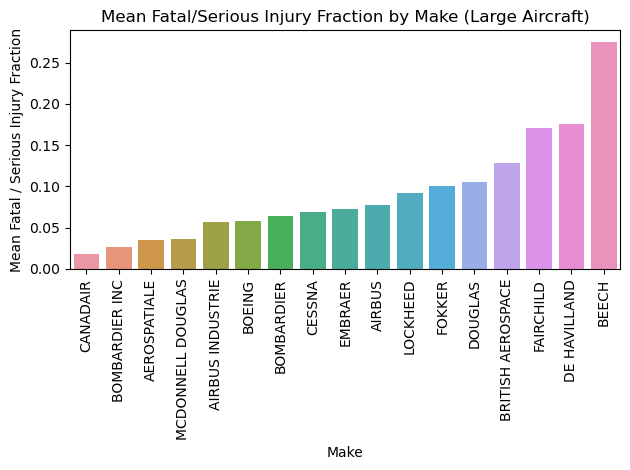

c:\Users\dkimasar.CO-OPBANK\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\dkimasar.CO-OPBANK\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


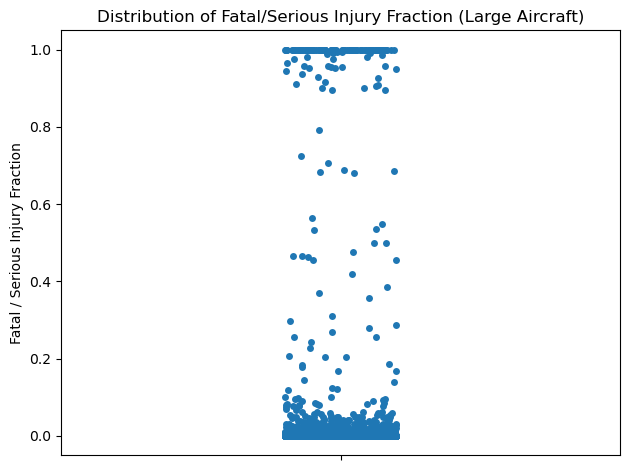

In [12]:
#Large planes analysis

large_df = filtered_df[filtered_df["Aircraft_Size"] == "Large"]

# Mean fatal/serious injury fraction (by Make)
large_make_stats = (
    large_df.groupby("Make")["Fatal_Serious_Fraction"]
    .mean()
    .reset_index()
    .sort_values("Fatal_Serious_Fraction")
)

# Mean plot (overall large planes)
sns.barplot(
    data=large_make_stats,
    x="Make",
    y="Fatal_Serious_Fraction"
)

plt.title("Mean Fatal/Serious Injury Fraction by Make (Large Aircraft)")
plt.xticks(rotation=90)
plt.ylabel("Mean Fatal / Serious Injury Fraction")
plt.tight_layout()
plt.show()

# Distribution plot (stripplot)
sns.stripplot(
    data=large_df,
    y="Fatal_Serious_Fraction"
)

plt.title("Distribution of Fatal/Serious Injury Fraction (Large Aircraft)")
plt.ylabel("Fatal / Serious Injury Fraction")
plt.tight_layout()
plt.show()



**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

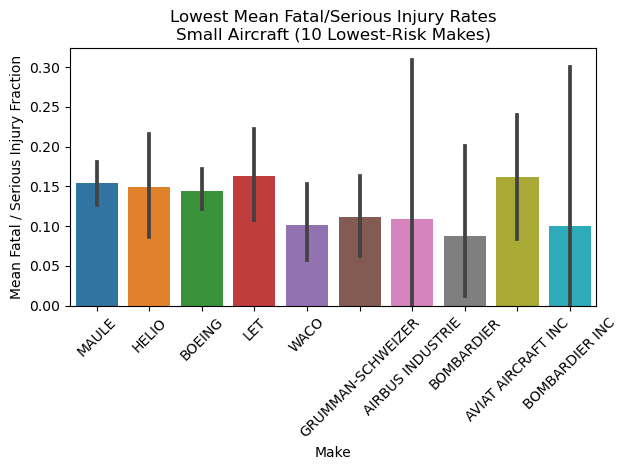

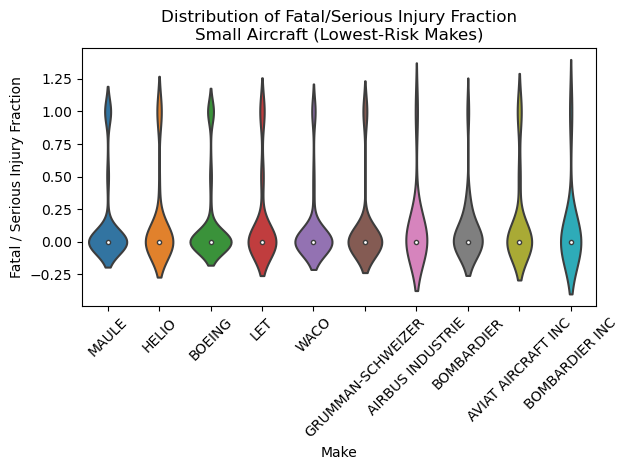

In [16]:
# Small planes analysis (lowest-risk makes only)

mall_df = filtered_df[filtered_df["Aircraft_Size"] == "Small"]

# Calculate mean injury rates by Make
small_make_stats = (
    small_df.groupby("Make")["Fatal_Serious_Fraction"]
    .mean()
    .sort_values()
)

# Select 10 lowest-risk makes
lowest_10_small = small_make_stats.head(10).index

small_low_df = small_df[small_df["Make"].isin(lowest_10_small)]

# Mean plot
sns.barplot(
    data=small_low_df,
    x="Make",
    y="Fatal_Serious_Fraction",
    estimator="mean"
)

plt.title("Lowest Mean Fatal/Serious Injury Rates\nSmall Aircraft (10 Lowest-Risk Makes)")
plt.xticks(rotation=45)
plt.ylabel("Mean Fatal / Serious Injury Fraction")
plt.tight_layout()
plt.savefig("Lowest-Risk Makes.png", bbox_inches="tight", dpi=150)
plt.show()

# Distribution plot (violin or strip)
sns.violinplot(
    data=small_low_df,
    x="Make",
    y="Fatal_Serious_Fraction"
)

plt.title("Distribution of Fatal/Serious Injury Fraction\nSmall Aircraft (Lowest-Risk Makes)")
plt.xticks(rotation=45)
plt.ylabel("Fatal / Serious Injury Fraction")
plt.tight_layout()
plt.show()


### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Large aircrafts 
From the mean fatal/serious injury fraction by make (large aircraft) bar chart and the accompanying distribution plot:
•	Most large-aircraft manufacturers exhibit very low mean fatal/serious injury fractions, generally clustered close to zero.
•	Well known commercial manufacturers such as Boeing, Airbus, Embraer, and Bombardier appear on the lower end of the mean injury spectrum.
•	A small number of manufacturers (e.g., those at the right end of the bar chart such as Beech and de Havilland) show notably higher mean fatal/serious injury fractions relative to the rest.

Small aircrafts: 
The plots focusing on the 10 lowest risk small aircraft makes reveal a different risk structure:
•	Even among the lowest risk small aircraft makes (e.g., Maule, Helio, Waco, LET, Grumman Schweizer, Aviat Aircraft Inc), mean fatal/serious injury fractions are higher than for most large aircraft makes.
•	Error bars indicate substantial variability around the means, suggesting less consistent outcomes across incidents.
•	No small aircraft make exhibits the same tight clustering near zero seen for large commercial aircraft.

Overally, passenger fatal/serious injury risk is substantially lower and more stable for large commercial aircraft than for small aircraft models.





### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

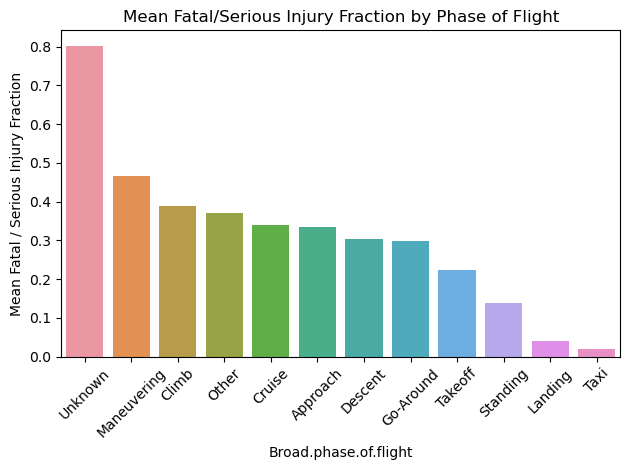

In [18]:
# Phase of Flight analysis

phase_stats = (
    df.groupby("Broad.phase.of.flight")
    .agg(
        mean_injury=("Fatal_Serious_Fraction", "mean"),
        mean_destroyed=("Destroyed", "mean"),
        count=("Fatal_Serious_Fraction", "size")
    )
    .query("count >= 20")
    .sort_values("mean_injury", ascending=False)
)

phase_stats.head()


sns.barplot(
    data=phase_stats.reset_index(),
    x="Broad.phase.of.flight",
    y="mean_injury"
)

plt.title("Mean Fatal/Serious Injury Fraction by Phase of Flight")
plt.ylabel("Mean Fatal / Serious Injury Fraction")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("injury_fraction_by_phase_of_flight.png", bbox_inches="tight", dpi=150)
plt.show()


## Discussion on phase of flight 
•The chart demonstrates that severity of outcomes (fatal or serious injury) is not the same as likelihood of an accident. Some phases may experience more incidents overall, but mid flight and maneuvering phases tend to result in more severe consequences when accidents do occur. 
• The exceptionally high value for “Unknown” underscores the importance of accurate phase of flight classification, as missing or ambiguous data appears correlated with severe injury outcomes. 
• From a safety and risk management perspective: 
    Training, monitoring, and procedural controls should pay particular attention to maneuvering and climb phases.
    Data quality improvements could materially enhance safety insights by reducing reliance on the “Unknown” category.


In [19]:
# FACTOR NUMBER 2
# Number of Engines analysis

engine_stats = (
    df.groupby("Number.of.Engines")
    .agg(
        mean_injury=("Fatal_Serious_Fraction", "mean"),
        mean_destroyed=("Destroyed", "mean"),
        count=("Fatal_Serious_Fraction", "size")
    )
    .query("count >= 20")
    .sort_values("mean_injury", ascending=False)
)

engine_stats


,mean_injury,mean_destroyed,count
Number.of.Engines,,,
2.0,0.295535,0.267631,9401
0.0,0.289777,0.142053,711
1.0,0.252867,0.189037,54402
4.0,0.126857,0.131926,379
3.0,0.028756,0.039906,426


### Discussion on number of engines  
The table shows a clear relationship between the number of engines and both injury severity and aircraft destruction outcomes, based on a large sample of incidents. Aircraft with one or two engines, which also make up the majority of cases (especially single‑engine with over 54,000 observations), have relatively high mean fatal/serious injury fractions (around 0.25–0.30) and moderate destroyed fractions, indicating greater risk to occupants when accidents occur. In contrast, three‑ and four‑engine aircraft—while much less common—exhibit substantially lower mean injury and destruction fractions, with three‑engine aircraft in particular showing very low average injury severity (≈0.03). Zero‑engine cases (likely gliders or similar aircraft) show moderate injury and lower destruction rates but are based on a much smaller sample. Overall, the statistics suggest that aircraft with more engines tend to be associated with less severe passenger outcomes and lower destruction likelihood, though these results should be interpreted alongside exposure and operational context, given the large imbalance in sample sizes across engine categories.